In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from groq import Groq
from langchain_groq import ChatGroq
from langchain.messages import RemoveMessage
load_dotenv()


True

In [2]:
model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.3
)

In [3]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 3:
        to_remove = msgs[:2]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [4]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [5]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [6]:
graph = builder.compile(checkpointer=InMemorySaver())

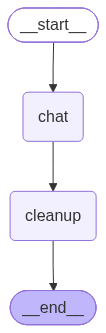

In [7]:
graph

In [8]:
config = {"configurable": {"thread_id": "t1"}}

In [9]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Teja"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)


{'messages': [HumanMessage(content='Now explain checkpointers', additional_kwargs={}, response_metadata={}, id='64e809b1-db02-424b-bff0-9bcc942d887f'),
  AIMessage(content='## Checkpointers in LangGraph  \n*(aka “state checkpointing / resume”)*  \n\nLangGraph’s **checkpointer** is the mechanism that lets you **pause**, **persist**, and later **resume** a graph execution exactly where it left off.  \nThink of it as a “save‑game” feature for LLM‑driven workflows: the runtime records the current node, the entire mutable `state` dictionary, and a tiny execution‑metadata blob. When you reload that blob you can continue the run without re‑invoking any of the already‑completed nodes.\n\nBelow is a deep‑dive covering:\n\n| Section | What you’ll learn |\n|---------|-------------------|\n| 1️⃣ What a checkpoint contains | The data structures that are serialized. |\n| 2️⃣ Why you need it | Real‑world scenarios where checkpointing is a must. |\n| 3️⃣ Built‑in checkpointer implementations | In‑memo

In [10]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 2
